In [50]:
import sys
# Uncomment the lines below to install required libraries
#!{sys.executable} -m pip install pandas openpyxl plotly
#!{sys.executable} -m pip install matplotlib seaborn

In [51]:
import os
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime
from IPython.display import display, HTML

# Project root
BASE_DIR  = Path(r"c:\Users\Usuario\Documents\Monroe County ORRI")
DATA_FILE = BASE_DIR / "Monroe County ORRI — Project Log FLATRIVER (1).xlsx"

def clean_hg(val):
    """Extract contract IDs (OH / UMD format) from a raw cell value."""
    if pd.isna(val) or str(val).strip().lower() in ["", "n/a", "none", "nan"]:
        return None
    v = str(val).upper().strip()
    match = re.search(r"(OH[-_ \s]*\d{4,5}[-_ \s]*\d{2}|UMD[-_ \s]*\d{5,6}[-_ \s]*\d{2,3})", v)
    if match:
        v = match.group(1)
    else:
        v = re.split(r"[\s_]", v)[0]
    return re.sub(r"[^A-Z0-9]", "", v)

print(f"Project root : {BASE_DIR}")
print(f"Data file    : {DATA_FILE.name}")

Project root : c:\Users\Usuario\Documents\Monroe County ORRI
Data file    : Monroe County ORRI — Project Log FLATRIVER (1).xlsx


In [52]:
print("Loading Monroe County ORRI data...")

if not DATA_FILE.exists():
    raise FileNotFoundError(f"Data file not found: {DATA_FILE}")

df_monroe_db = pd.read_excel(DATA_FILE, sheet_name="DB FINDING")
monroe_filename = DATA_FILE.name

print(f"  File   : {monroe_filename}")
print(f"  Rows   : {len(df_monroe_db)}")
print(f"  Columns: {list(df_monroe_db.columns)}")

Loading Monroe County ORRI data...
  File   : Monroe County ORRI — Project Log FLATRIVER (1).xlsx
  Rows   : 536
  Columns: ['Heritage Lease Name', 'Lookup Township', 'Surface Parcel', 'Book/Page', 'Landman', 'Lease Found', 'Township Found', 'Surface Parcel Found', 'Lease date', 'Notes', 'Township', 'Range', 'Section', 'Date Completion', 'Match T, R,  S', 'Surface Parcel.1', 'Match Acres', 'Match Lessor', 'Posible Matches', 'Was it found?', 'Website Lease URL', 'SELLER', 'FORMATED DATE', 'DEAL NAME']


In [53]:
print("⚙️ Restructuring Logic: Asset Directory with Concatenated Parcels...")

# 1. Load Primary Monroe Data
df_db = pd.read_excel(DATA_FILE, sheet_name="DB FINDING")

# 2. Setup Columns
id_col = df_db.columns[0]
twn_col = df_db.columns[1]
prc_col = df_db.columns[2]
sel_col = next((c for c in df_db.columns if 'seller' in str(c).lower()), None)
time_col = df_db.columns[8]

# Create a unique-id based dataframe for counts
df_unique = df_db.drop_duplicates(subset=[id_col], keep='first').copy()

# --- Geo Integrity ---
township_id = int(df_unique[twn_col].notna().sum())
township_missing = int(len(df_unique) - township_id)
parcel_id = int(df_unique[prc_col].notna().sum())
parcel_missing = int(len(df_unique) - parcel_id)

# --- Geographical Spread ---
twn_dist = df_unique[twn_col].value_counts().sort_values(ascending=True)
twn_labels = twn_dist.index.astype(str).tolist()
twn_values = twn_dist.values.tolist()

# --- Asset Directory (Concatenated Parcels) ---
directory_list = []
# Group by ID to get all parcels for each lease
grouped_parcels = df_db.groupby(id_col)[prc_col].apply(lambda x: ', '.join(x.dropna().astype(str).unique())).to_dict()

for _, row in df_unique.iterrows():
    lease_id = str(row[id_col])
    directory_list.append({
        "id": lease_id,
        "sel": str(row[sel_col]) if pd.notna(row[sel_col]) else "N/A",
        "twn": str(row[twn_col]) if pd.notna(row[twn_col]) else "N/A",
        "prc": grouped_parcels.get(lease_id, "N/A")
    })

# --- Seller Distribution ---
seller_counts = df_unique[sel_col].value_counts().to_dict() if sel_col else {}

# --- Missing Parcel UMD split ---
no_prc_mask = (
    df_unique[prc_col].isna() |
    df_unique[prc_col].astype(str).str.strip().eq('') |
    df_unique[prc_col].astype(str).str.strip().str.lower().eq('nan')
)
df_no_prc  = df_unique[no_prc_mask]
no_prc_umd   = int(df_no_prc[id_col].astype(str).str.upper().str.startswith('UMD').sum())
no_prc_other = int(len(df_no_prc) - no_prc_umd)

# --- Blank Seller UMD split ---
if sel_col:
    blank_mask = (
        df_unique[sel_col].isna() |
        df_unique[sel_col].astype(str).str.strip().eq('') |
        df_unique[sel_col].astype(str).str.strip().str.lower().eq('nan')
    )
    df_no_sel    = df_unique[blank_mask]
    no_sel_count = int(blank_mask.sum())
    no_sel_umd   = int(df_no_sel[id_col].astype(str).str.upper().str.startswith('UMD').sum())
    no_sel_other = int(no_sel_count - no_sel_umd)
else:
    no_sel_count, no_sel_umd, no_sel_other = 0, 0, 0

# --- Seller Integrity ---
seller_id      = int((~blank_mask).sum()) if sel_col else len(df_unique)
seller_missing = no_sel_count

# --- Incomplete Leases Directory ---
incomplete_list = []
for _, irow in df_unique.iterrows():
    miss = []
    twn_v = str(irow[twn_col]).strip() if pd.notna(irow[twn_col]) else ''
    if twn_v.lower() in ('', 'nan'): miss.append('Township')
    prc_v = grouped_parcels.get(str(irow[id_col]), '')
    if not prc_v or prc_v.lower() == 'nan': miss.append('Parcel')
    if sel_col:
        sel_v = str(irow[sel_col]).strip() if pd.notna(irow[sel_col]) else ''
        if sel_v.lower() in ('', 'nan'): miss.append('Seller')
    else:
        sel_v = ''
    if miss:
        incomplete_list.append({
            'id':   str(irow[id_col]),
            'twn':  twn_v or 'N/A',
            'prc':  prc_v or 'N/A',
            'sel':  sel_v or 'N/A',
            'miss': ', '.join(miss)
        })

# --- Timeline ---
t_years, t_counts = [], []
if time_col in df_db.columns:
    dates_series = pd.to_datetime(df_db[time_col], errors='coerce')
    valid_yrs = dates_series.dt.year.dropna().astype(int)
    if not valid_yrs.empty:
        bin_starts = valid_yrs - (valid_yrs % 5)
        vcounts = bin_starts.value_counts().sort_index()
        t_years = [f"{y}-{y+4}" for y in vcounts.index]
        t_counts = vcounts.values.tolist()

# --- Flow ---
flow_data = df_db.groupby([sel_col, twn_col]).size().reset_index(name='val') if sel_col and twn_col else pd.DataFrame()
nodes = list(set(flow_data[sel_col].unique().tolist() + flow_data[twn_col].unique().tolist())) if not flow_data.empty else []

# --- Missing Breakdown ---
missing_rows = df_unique[df_unique[twn_col].isna()]
ids = missing_rows[id_col].fillna("").astype(str)
umd_missing  = int(ids.str.upper().str.contains("UMD").sum())
other_missing = int(len(ids) - umd_missing)

master_data = {
    "Primary View": {
        "geo_integrity_twn": [township_id, township_missing],
        "geo_integrity_prc": [parcel_id, parcel_missing],
        "missing_split": {"UMD": int(umd_missing), "Other": int(other_missing)},
        "time_y": t_years, "time_c": t_counts,
        "twn_l": twn_labels, "twn_v": twn_values,
        "directory": directory_list,
        "pie_l": list(seller_counts.keys())[:10], "pie_v": [int(x) for x in list(seller_counts.values())][:10],
        "san_n": nodes,
        "san_s": [nodes.index(s) for s in flow_data[sel_col]] if nodes else [],
        "san_t": [nodes.index(t) for t in flow_data[twn_col]] if nodes else [],
        "san_v": [int(v) for v in flow_data['val']] if nodes else [],
        "no_prc_umd": no_prc_umd,
        "no_prc_other": no_prc_other,
        "no_sel_count": no_sel_count,
        "no_sel_umd": no_sel_umd,
        "no_sel_other": no_sel_other,
        "seller_id": seller_id,
        "seller_missing": seller_missing,
        "incomplete_dir": incomplete_list
    }
}

json_master = json.dumps(master_data)
print("✅ Asset Directory updated and Syntax errors fixed.")

⚙️ Restructuring Logic: Asset Directory with Concatenated Parcels...
✅ Asset Directory updated and Syntax errors fixed.


In [54]:
# NOTE: Exports a 3-way audit report when df_results is available from a
# separate audit workflow. Skip if that workflow has not been run.
if "df_results" in dir() and not df_results.empty:
    out_path = BASE_DIR / "Global_3_Way_Audit.xlsx"
    exp_audit = df_results[["Original_Format","Monroe_Val","PDF_Val","Ult_Val","Match Status"]].copy()
    exp_audit.columns = ["Contract ID","Monroe Value","PDF Value","Ultimate Value","Diagnostic Result"]
    exp_audit.to_excel(out_path, index=False)
    print(f"Audit saved -> {out_path}")
else:
    print("df_results not available — skipping audit export.")

df_results not available — skipping audit export.


In [55]:
from IPython.display import display, HTML

if 'json_master' in locals():
    # Usamos dobles llaves {{ }} para escapar el CSS y JS dentro del f-string de Python
    html_dashboard = f"""
    <!DOCTYPE html>
    <html lang='en'>
    <head>
        <meta charset='UTF-8'>
        <title>Asset Intelligence Dashboard</title>
        <script src='https://cdn.plot.ly/plotly-2.27.0.min.js'></script>
        <link href='https://fonts.googleapis.com/css2?family=Outfit:wght@300;700;900&display=swap' rel='stylesheet'>
        <style>
            body {{ background: #F8FAFC; font-family: 'Outfit', sans-serif; padding: 20px; color: #1E293B; }}
            .panel {{ background: #FFF; border-radius: 15px; padding: 25px; margin-bottom: 20px; box-shadow: 0 4px 15px rgba(0,0,0,0.05); }}
            .grid {{ display: grid; grid-template-columns: 1fr 1fr; gap: 20px; }}
            .chart {{ height: 400px; }}
            .full-grid {{ grid-column: span 2; }}
            .table-container {{ overflow-y: auto; max-height: 500px; }}
            table {{ width: 100%; border-collapse: collapse; font-size: 13px; }}
            th {{ position: sticky; top: 0; background: #EEF2FF; color: #6366F1; text-align: left; padding: 12px; font-weight: 900; }}
            td {{ padding: 10px; border-bottom: 1px solid #F1F5F9; word-break: break-all; }}
            h1 {{ font-weight: 900; font-size: 26px; border-left: 6px solid #6366F1; padding-left: 15px; margin-bottom: 25px; }}
            h3 {{ font-weight: 900; margin-top: 0; }}
            .pagination {{ display:flex; align-items:center; gap:10px; margin-top:12px; }}
            .pg-btn {{ background:#6366F1; color:#fff; border:none; border-radius:8px;
                       padding:6px 16px; cursor:pointer; font-family:inherit; font-weight:700; }}
            .pg-btn:disabled {{ background:#C7D2FE; cursor:default; }}
            .pg-info {{ font-size:13px; color:#64748B; }}
            .legend {{ display:flex; gap:12px; flex-wrap:wrap; margin-bottom:10px; font-size:12px; }}
            .badge {{ padding:3px 10px; border-radius:5px; }}
        </style>
    </head>
    <body>
        <h1>Asset & Geographic Intelligence</h1>

        <div class='grid'>
            <div class='panel chart' id='chart-time'></div>
            <div class='panel chart' id='chart-spread'></div>

            <div class='full-grid' style='display:grid; grid-template-columns:1fr 1fr 1fr; gap:20px;'>
                <div class='panel chart' id='chart-twn'></div>
                <div class='panel chart' id='chart-prc'></div>
                <div class='panel chart' id='chart-seller'></div>
            </div>

            <div class='panel full-grid'>
                <h3>Asset Directory</h3>
                <div class='table-container'>
                    <table id='dir-table'>
                        <thead><tr><th>ID</th><th>Seller</th><th>Township</th><th>Parcels</th></tr></thead>
                        <tbody></tbody>
                    </table>
                </div>
                <div class='pagination'>
                    <button class='pg-btn' id='pg-prev' onclick='changePage(-1)'>&#8592; Prev</button>
                    <span class='pg-info' id='pg-info'></span>
                    <button class='pg-btn' id='pg-next' onclick='changePage(1)'>Next &#8594;</button>
                </div>
            </div>

            <div class='panel chart full-grid' style='height:500px;' id='chart-sankey'></div>

            <div class='panel chart' id='chart-no-parcel-umd'></div>
            <div class='panel chart' id='chart-no-seller-umd'></div>

            <div class='panel full-grid'>
                <h3>Incomplete Leases <span id='inc-count' style='font-weight:400; font-size:13px; color:#94A3B8;'></span></h3>
                <div class='legend'>
                    <span class='badge' style='background:#FEF3C7;'>&#9632; Missing Township</span>
                    <span class='badge' style='background:#DBEAFE;'>&#9632; Missing Parcel</span>
                    <span class='badge' style='background:#EDE9FE;'>&#9632; Missing Seller</span>
                    <span class='badge' style='background:#FFE4E6;'>&#9632; Multiple Missing</span>
                </div>
                <div class='table-container'>
                    <table id='inc-table'>
                        <thead><tr><th>ID</th><th>Township</th><th>Parcel</th><th>Seller</th><th>Missing Fields</th></tr></thead>
                        <tbody></tbody>
                    </table>
                </div>
            </div>
        </div>

        <script>
            const data = {json_master}['Primary View'];
            const layout = (title, hole=0.5) => ({{
                title: {{ text: title, font: {{ size: 16, weight: 900 }} }},
                hole: hole, margin: {{t:50, b:40, l:80, r:20}},
                paper_bgcolor: 'rgba(0,0,0,0)', plot_bgcolor: 'rgba(0,0,0,0)'
            }});

            const viridis = ['#440154', '#482878', '#3e4989', '#31688e', '#26828e', '#1f9e89', '#35b779', '#6ece58', '#b5de2b', '#fde725'];

            Plotly.newPlot('chart-time', [{{
                type: 'bar', x: data.time_y, y: data.time_c,
                marker: {{ color: data.time_y.map(function(v, i) {{ return viridis[i % 10]; }}) }}
            }}], {{
                title: {{ text: 'Acquisition Waves', font: {{ size: 15, weight: 900 }} }},
                margin: {{t:50, b:90, l:60, r:20}},
                paper_bgcolor: 'rgba(0,0,0,0)', plot_bgcolor: 'rgba(0,0,0,0)',
                xaxis: {{ tickangle: -45, tickfont: {{ size: 10 }}, automargin: true }},
                yaxis: {{ tickfont: {{ size: 11 }} }}
            }});

            Plotly.newPlot('chart-spread', [{{
                type: 'bar', orientation: 'h', x: data.twn_v, y: data.twn_l,
                marker: {{ color: '#6366F1' }}
            }}], {{
                title: {{ text: 'Geographical Spread', font: {{ size: 15, weight: 900 }} }},
                margin: {{t:50, b:40, l:160, r:40}},
                paper_bgcolor: 'rgba(0,0,0,0)', plot_bgcolor: 'rgba(0,0,0,0)',
                yaxis: {{ tickfont: {{ size: 10 }}, automargin: true }},
                xaxis: {{ tickfont: {{ size: 11 }} }}
            }});

            Plotly.newPlot('chart-twn', [{{ type: 'pie', labels: ['Identified', 'Missing'], values: data.geo_integrity_twn, marker: {{colors:['#10B981','#F43F5E']}} }}], layout('Township Integrity'));
            Plotly.newPlot('chart-prc', [{{ type: 'pie', labels: ['Identified', 'Missing'], values: data.geo_integrity_prc, marker: {{colors:['#3B82F6','#F59E0B']}} }}], layout('Parcel Integrity'));
            Plotly.newPlot('chart-seller', [{{ type: 'pie', labels: ['Identified', 'Missing'], values: [data.seller_id, data.seller_missing], marker: {{colors:['#8B5CF6','#F43F5E']}} }}], layout('Seller Integrity'));

            // ── Paginated Asset Directory ────────────────────────
            const PAGE_SIZE = 10;
            let currentPage = 0;
            const tbody = document.querySelector('#dir-table tbody');

            function renderPage(page) {{
                const total = data.directory.length;
                const totalPages = Math.ceil(total / PAGE_SIZE);
                const start = page * PAGE_SIZE;
                const slice = data.directory.slice(start, start + PAGE_SIZE);
                tbody.innerHTML = '';
                slice.forEach(function(row) {{
                    const tr = document.createElement('tr');
                    tr.innerHTML = '<td>' + row.id + '</td><td>' + row.sel + '</td><td>' + row.twn + '</td><td>' + row.prc + '</td>';
                    tbody.appendChild(tr);
                }});
                document.getElementById('pg-info').textContent =
                    'Page ' + (page + 1) + ' of ' + totalPages + '  (' + total + ' leases)';
                document.getElementById('pg-prev').disabled = (page === 0);
                document.getElementById('pg-next').disabled = (page >= totalPages - 1);
            }}

            function changePage(delta) {{
                currentPage += delta;
                renderPage(currentPage);
            }}

            renderPage(0);

            if(data.san_n.length > 0) {{
                Plotly.newPlot('chart-sankey', [{{
                    type: 'sankey',
                    node: {{ pad: 15, thickness: 20, label: data.san_n, color: '#6366F1' }},
                    link: {{ source: data.san_s, target: data.san_t, value: data.san_v, color: 'rgba(99, 102, 241, 0.2)' }}
                }}], layout('Asset Flow: Seller to Township', 0));
            }}

            // ── Pie 1: Missing Parcels — UMD vs Other ────────────
            Plotly.newPlot('chart-no-parcel-umd', [{{
                type: 'pie',
                labels: ['UMD', 'Other'],
                values: [data.no_prc_umd, data.no_prc_other],
                marker: {{ colors: ['#F59E0B', '#94A3B8'] }},
                textinfo: 'label+value+percent',
                hole: 0.4
            }}], {{
                title: {{ text: 'Missing Parcels — UMD vs Other', font: {{ size: 15, weight: 900 }} }},
                margin: {{t:60, b:30, l:30, r:30}},
                paper_bgcolor: 'rgba(0,0,0,0)'
            }});

            // ── Pie 2: No Seller — UMD vs Other ──────────────────
            Plotly.newPlot('chart-no-seller-umd', [{{
                type: 'pie',
                labels: ['UMD', 'Other'],
                values: [data.no_sel_umd, data.no_sel_other],
                marker: {{ colors: ['#F43F5E', '#94A3B8'] }},
                textinfo: 'label+value+percent',
                hole: 0.4
            }}], {{
                title: {{ text: 'No Seller (' + data.no_sel_count + ' total) — UMD vs Other', font: {{ size: 15, weight: 900 }} }},
                margin: {{t:60, b:30, l:30, r:30}},
                paper_bgcolor: 'rgba(0,0,0,0)'
            }});

            // ── Incomplete Leases Directory ──────────────────────
            const MISS_BG = {{
                'Township': '#FEF3C7',
                'Parcel':   '#DBEAFE',
                'Seller':   '#EDE9FE'
            }};
            const incDir = data.incomplete_dir || [];
            document.getElementById('inc-count').textContent = '(' + incDir.length + ' leases)';
            const incTbody = document.querySelector('#inc-table tbody');
            incDir.forEach(function(row) {{
                const fields = row.miss.split(', ');
                const bg = fields.length > 1 ? '#FFE4E6' : (MISS_BG[fields[0]] || '#F1F5F9');
                const tr = document.createElement('tr');
                tr.style.background = bg;
                tr.innerHTML = '<td>' + row.id + '</td><td>' + row.twn + '</td><td>' + row.prc + '</td><td>' + row.sel + '</td><td><strong>' + row.miss + '</strong></td>';
                incTbody.appendChild(tr);
            }});
        </script>
    </body>
    </html>
    """
    display(HTML(html_dashboard))
else:
    print("⚠️ Run processing cells first.")

In [56]:
if "html_dashboard" in dir():
    out_html = BASE_DIR / "Asset_Intelligence_Report.html"
    with open(out_html, "w", encoding="utf-8") as f:
        f.write(html_dashboard)
    print(f"Dashboard saved -> {out_html}")
else:
    print("html_dashboard not found. Run the dashboard cell first.")

Dashboard saved -> c:\Users\Usuario\Documents\Monroe County ORRI\Asset_Intelligence_Report.html


📊 Generating Acquisition Waves Histogram from Column I...


C:\Users\Usuario\AppData\Local\Temp\ipykernel_21128\1107882935.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=vcounts.values, palette='viridis')


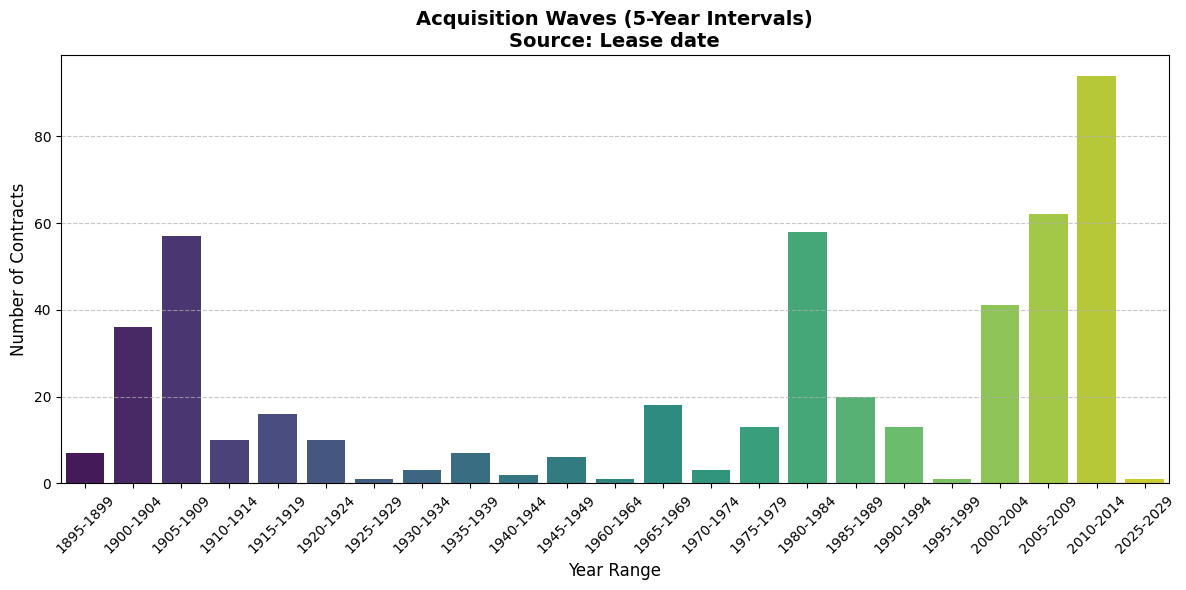

✅ Successfully plotted 480 records from column 'Lease date'.


In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

print("📊 Generating Acquisition Waves Histogram from Column I...")

# 1. Identify Column I (index 8)
if not df_db.empty and len(df_db.columns) >= 9:
    time_col = df_db.columns[8]

    # 2. Extract and parse dates
    dates_series = pd.to_datetime(df_db[time_col], errors='coerce')
    valid_yrs = dates_series.dt.year.dropna().astype(int)

    if not valid_yrs.empty:
        # 3. Create 5-year bins
        bin_starts = valid_yrs - (valid_yrs % 5)
        vcounts = bin_starts.value_counts().sort_index()
        labels = [f"{y}-{y+4}" for y in vcounts.index]

        # 4. Plotting
        plt.figure(figsize=(12, 6))
        sns.barplot(x=labels, y=vcounts.values, palette='viridis')

        plt.title(f'Acquisition Waves (5-Year Intervals)\nSource: {time_col}', fontsize=14, fontweight='bold')
        plt.xlabel('Year Range', fontsize=12)
        plt.ylabel('Number of Contracts', fontsize=12)
        plt.xticks(rotation=45)
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()

        print(f"✅ Successfully plotted {len(valid_yrs)} records from column '{time_col}'.")
    else:
        print("⚠️ No valid dates found in Column I.")
else:
    print("⚠️ Monroe database is empty or Column I is missing.")